In [60]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from pathlib import Path

from PIL import Image
import os

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights

from collections import Counter
import hashlib

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [61]:
def file_hash(path):

    ## Return hashed library for image leakage between training and testing sets
    with open(path, "rb") as f:
        return hashlib.md5(
            f.read()
        ).hexdigest()


In [62]:
def collect_image_hashes(folder, dataset_name):
    ## Create the image hashes to see image leakage between training and testing sets

    records = []

    for path in Path(folder).rglob("*"):

        records.append({
            "dataset": dataset_name,
            "class": path.parent.name,
            "filename": path.name,
            "path": str(path),
            "hash": file_hash(path)})

    return records

In [63]:
## Load pre-trained weights from ResNet18 convolutional neural network

weights = ResNet18_Weights.DEFAULT

# Name for transformations needed for the images to be processed
transform = weights.transforms()

# Loading and saving training and testing datasets as separated in images folder
train_dataset = ImageFolder("images/training", transform=transform)
test_dataset = ImageFolder("images/testing", transform=transform)

# Records in terms of hashes for the training image set
train_records = collect_image_hashes(
    "images/training",
    "training"
)

# Records in terms of hashes for the testing image set
test_records = collect_image_hashes(
    "images/testing",
    "testing"
)

# Dataframe appending both records
hash_df = pd.DataFrame(train_records + test_records)


IsADirectoryError: [Errno 21] Is a directory: 'images/training/flip'

In [ ]:
# Splits the training set randomly into batches of 32 images while training and testing

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Counts how many total images we're working with, to view any imbalance

print(Counter(train_dataset.targets))
print(train_dataset.class_to_idx)
# A flip is characterized as 0 and notflip is 1.
# It is, largely, equally balanced with flip and notflip images (1162:1230)


Counter({1: 1230, 0: 1162})
{'flip': 0, 'notflip': 1}


In [ ]:
# initialize records to compare hashes
records = []

for cls in ["flip", "notflip"]:
    folder = f"images/training/{cls}"

    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)

        try:
            img = Image.open(path)

            records.append({"class": cls,
                "filename": filename,
                "width": img.width,
                "height": img.height,
                "mode": img.mode})

        except Exception:
            print("Could not open:", path)

df = pd.DataFrame(records)

  class            filename  width  height mode
0  flip  0005_000000020.jpg   1080    1920  RGB
1  flip  0038_000000009.jpg   1080    1920  RGB
2  flip  0011_000000019.jpg   1080    1920  RGB
3  flip  0062_000000023.jpg   1080    1920  RGB
4  flip  0038_000000021.jpg   1080    1920  RGB
        width  height
count  2392.0  2392.0
mean   1080.0  1920.0
std       0.0     0.0
min    1080.0  1920.0
25%    1080.0  1920.0
50%    1080.0  1920.0
75%    1080.0  1920.0
max    1080.0  1920.0
          width                                                       height  \
          count    mean  std     min     25%     50%     75%     max   count   
class                                                                          
flip     1162.0  1080.0  0.0  1080.0  1080.0  1080.0  1080.0  1080.0  1162.0   
notflip  1230.0  1080.0  0.0  1080.0  1080.0  1080.0  1080.0  1080.0  1230.0   

                                                              
           mean  std     min     25%     50%     7

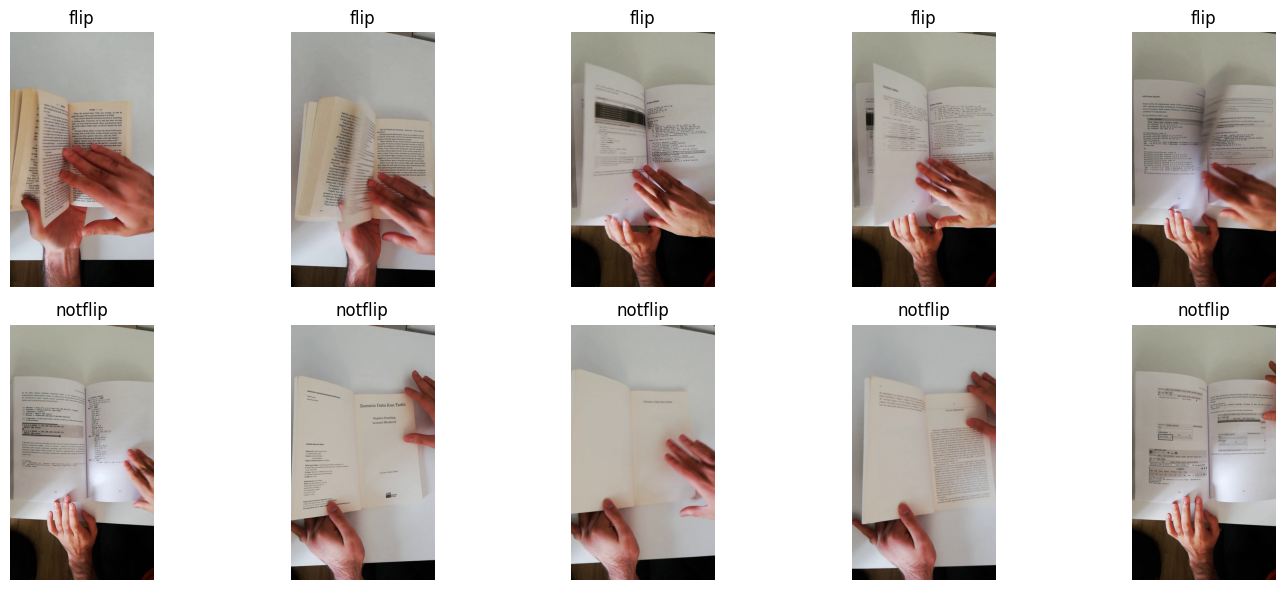

In [26]:
print(df.head())

print(df[["width", "height"]].describe())
print(df.groupby("class")[["width", "height"]].describe())

df["aspect_ratio"] = df["width"] / df["height"]

print(df.groupby("class")["aspect_ratio"].describe())

print(df["mode"].value_counts())

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, cls in enumerate(["flip", "notflip"]):

    folder = f"images/training/{cls}"
    files = random.sample(os.listdir(folder), 5)

    for col, filename in enumerate(files):

        img = Image.open(
            os.path.join(folder, filename)
        ).convert("RGB")

        axes[row, col].imshow(img)
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [27]:
# After running several times, the images are very similar in set up.

duplicates = hash_df[
    hash_df.duplicated("hash", keep=False)
].sort_values("hash")

print("These are the duplicates", duplicates)
# There are no duplicates.


train_hashes = set(
    hash_df.loc[
        hash_df["dataset"] == "training",
        "hash"
    ]
)

test_hashes = set(
    hash_df.loc[
        hash_df["dataset"] == "testing",
        "hash"
    ]
)

overlap = train_hashes.intersection(test_hashes)

print("Number of exact duplicates between train and test:", len(overlap))


train_test_duplicates = hash_df[
    hash_df["hash"].isin(overlap)
].sort_values("hash")

print(train_test_duplicates[
    ["dataset", "class", "filename", "path", "hash"]
])


These are the duplicates Empty DataFrame
Columns: [dataset, class, filename, path, hash]
Index: []
Number of exact duplicates between train and test: 0
Empty DataFrame
Columns: [dataset, class, filename, path, hash]
Index: []


In [ ]:
# Naming initial pre-trained model
model = resnet18(weights=weights)

# Changing outputs to just two, with the in-features
# Ensuring the parameters are not changed using backpropagation

for param in model.parameters():
    param.requires_grad = False

# Defining 
model.fc = nn.Linear(model.fc.in_features, 2)
print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [ ]:
indices = np.arange(len(train_dataset))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=train_dataset.targets,
    random_state=42)

train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(train_dataset, val_idx)

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False)

criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001)


if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model = model.to(device)

print(device)

mps
mps


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    train_accuracy = correct / total

    # Validation

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            val_correct += (predictions == labels).sum().item()

            val_total += labels.size(0)

    val_accuracy = val_correct / val_total

    print(f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {running_loss / len(train_loader):.4f} | "
        f"Train Acc: {train_accuracy:.3f} | "
        f"Val Loss: {val_loss / len(val_loader):.4f} | "
        f"Val Acc: {val_accuracy:.3f}")

Epoch 1/10 | Train Loss: 0.6030 | Train Acc: 0.667 | Val Loss: 0.4812 | Val Acc: 0.772
Epoch 2/10 | Train Loss: 0.4267 | Train Acc: 0.835 | Val Loss: 0.3815 | Val Acc: 0.848
Epoch 3/10 | Train Loss: 0.3631 | Train Acc: 0.865 | Val Loss: 0.3382 | Val Acc: 0.862
Epoch 4/10 | Train Loss: 0.3263 | Train Acc: 0.879 | Val Loss: 0.2930 | Val Acc: 0.881
Epoch 5/10 | Train Loss: 0.2906 | Train Acc: 0.890 | Val Loss: 0.2738 | Val Acc: 0.883
Epoch 6/10 | Train Loss: 0.2712 | Train Acc: 0.906 | Val Loss: 0.2606 | Val Acc: 0.877
Epoch 7/10 | Train Loss: 0.2614 | Train Acc: 0.909 | Val Loss: 0.2518 | Val Acc: 0.881
Epoch 8/10 | Train Loss: 0.2337 | Train Acc: 0.918 | Val Loss: 0.2328 | Val Acc: 0.896
Epoch 9/10 | Train Loss: 0.2328 | Train Acc: 0.924 | Val Loss: 0.2267 | Val Acc: 0.908
Epoch 10/10 | Train Loss: 0.2213 | Train Acc: 0.928 | Val Loss: 0.2550 | Val Acc: 0.896


In [32]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [ ]:
train_losses.append(running_loss / len(train_loader))

val_losses.append(val_loss / len(val_loader))

train_accuracies.append(train_accuracy)
val_accuracies.append(val_accuracy)

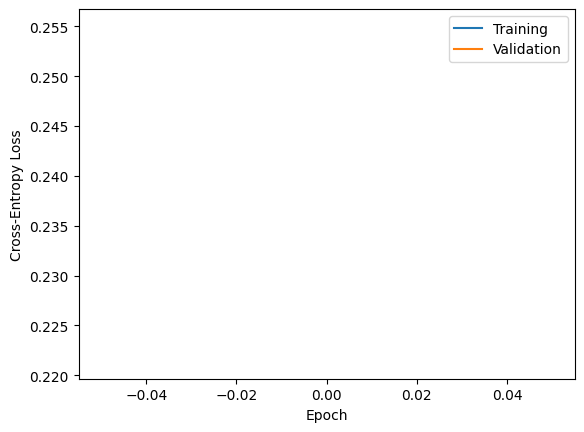

In [ ]:
# Find out how to plot the loss and accuracy.

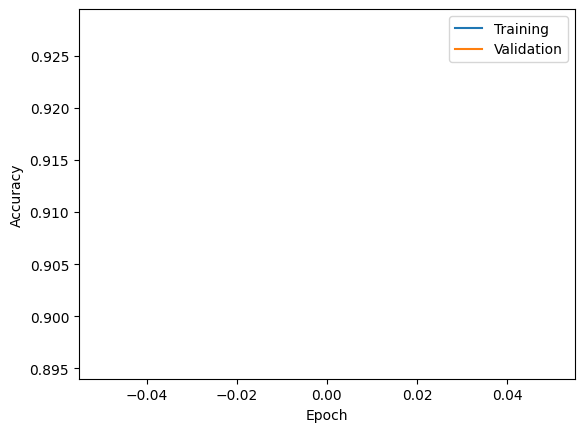

In [ ]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(
        all_labels,
        all_predictions,
        target_names=train_dataset.classes))

print(confusion_matrix(
        all_labels,
        all_predictions))

              precision    recall  f1-score   support

        flip       0.99      0.79      0.88       233
     notflip       0.84      0.99      0.91       246

    accuracy                           0.90       479
   macro avg       0.91      0.89      0.89       479
weighted avg       0.91      0.90      0.89       479

[[185  48]
 [  2 244]]
